In [1]:
import pandas as pd
import numpy as np
from glob import glob
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from matplotlib_venn import venn3

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import linregress

In [2]:
#function return r2 from linear regression between feature(s) and target
def get_r2(X, y):
    if len(X.shape)<2:
        r2 = LinearRegression().fit(StandardScaler().fit_transform(X.values.reshape(-1, 1)), y).score(StandardScaler().fit_transform(X.values.reshape(-1, 1)), y)
    else:
        r2 = LinearRegression().fit(StandardScaler().fit_transform(X.values), y).score(StandardScaler().fit_transform(X.values), y)
    return r2

In [3]:
#path to dir
path='/scratch2/alinat/project/PD-EEG-ANON_eegOnly/MLtables180'

In [46]:
best_r2_lvl1 = pd.read_csv(path+'/MLout/MLlvl1_bestPerf_r2_among6alg_STDonly_BT_withCI.csv', index_col=0)

best_r2_lvl1 = best_r2_lvl1.reindex(index=[i for i in best_r2_lvl1.index if any(band in i for band in ["aec_theta", "aec_alpha", "dwpli_theta"])])#.sort_index()


In [15]:
with open(glob(path+'/MLout/MLlvl1_predval_tabs_1targ_6algs_ZnoLG.pkl')[0], 'rb') as file:
    TABS = pickle.load(file)

In [64]:

age_orig = pd.read_csv(glob(path+'/*demog*.csv')[0], index_col=0)['Age'].sort_index()

cog_orig = TABS['global_z_no_language__enet']['y_obs'].sort_index()

sex_bio = pd.read_csv(glob(path+'/*demog*.csv')[0], index_col=0)['Sex'].sort_index()


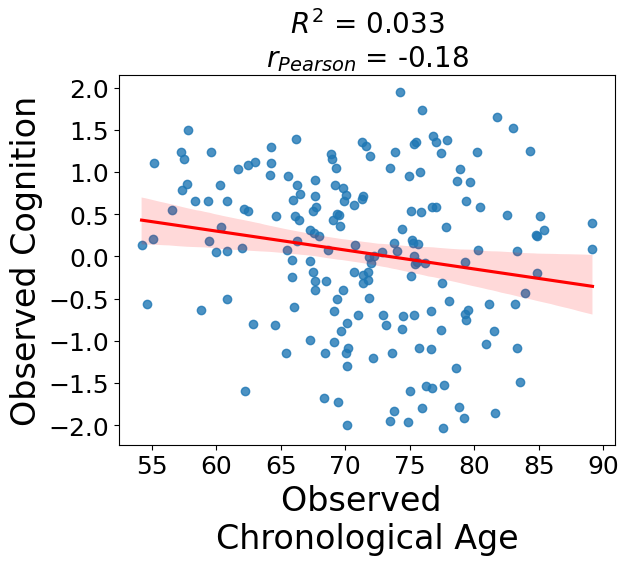

In [57]:
ind_r2 = np.round( get_r2(age_orig, cog_orig), 3)
ind_cor = pearsonr(age_orig, cog_orig)[0].round(3)


plt.title('$R^2$ = '+str(ind_r2)+'\n$r_{Pearson}$ = '+str(ind_cor)
          , fontsize=20)

sns.regplot(x = age_orig, 
            y = cog_orig,  
            line_kws={"color": "red"})
plt.xlabel('Observed \nChronological Age', fontsize=24)
plt.ylabel('Observed Cognition', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.show()

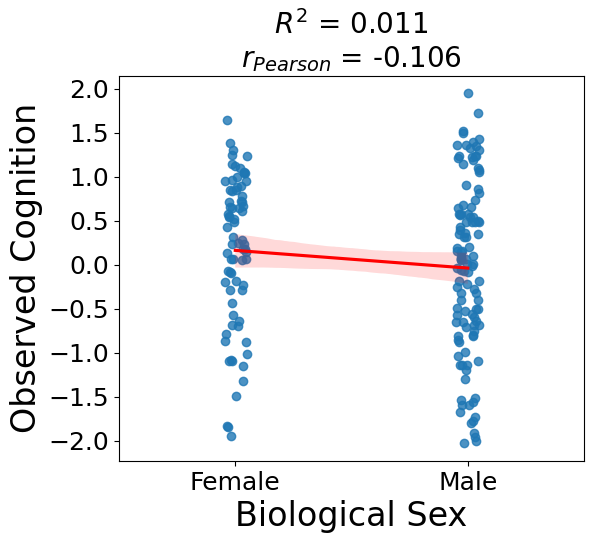

In [75]:
ind_r2 = np.round(get_r2(sex_bio, cog_orig), 3)
ind_cor = pearsonr(sex_bio, cog_orig)[0].round(3)

plt.figure(figsize=(6, 5))

plt.title(
    '$R^2$ = ' + str(ind_r2) + '\n$r_{Pearson}$ = ' + str(ind_cor),
    fontsize=20
)

sns.regplot(
    x=sex_bio,
    y=cog_orig,
    line_kws={"color": "red"},
    x_jitter=0.05
)

plt.xlabel('Biological Sex', fontsize=24)
plt.ylabel('Observed Cognition', fontsize=24)

plt.xticks([0, 1], ["Female", "Male"], fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(-0.5, 1.5)

plt.show()

In [40]:
df_predval_bestmod = {}
for mod in best_r2_lvl1.index:
    md, alg = mod.split('___')
    df_predval_bestmod[mod]= TABS['global_z_no_language__'+alg][md]
df_predval_bestmod = pd.DataFrame(df_predval_bestmod).sort_index()


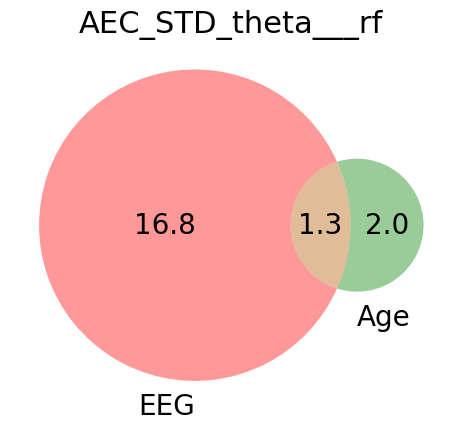

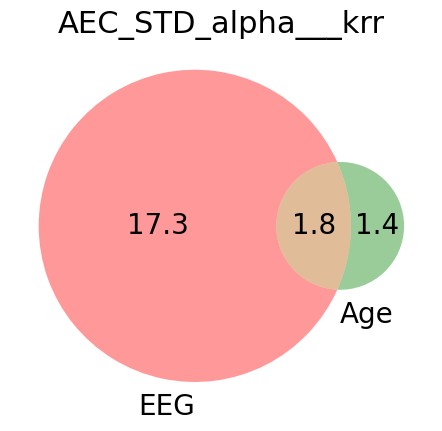

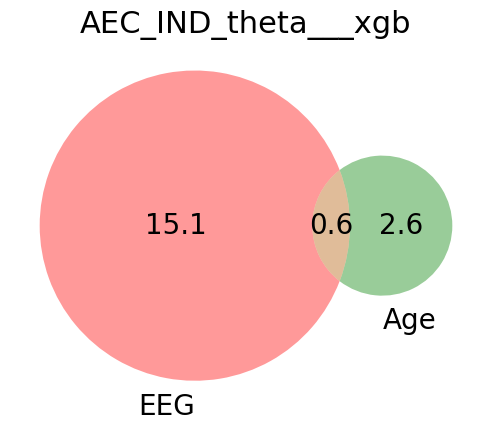

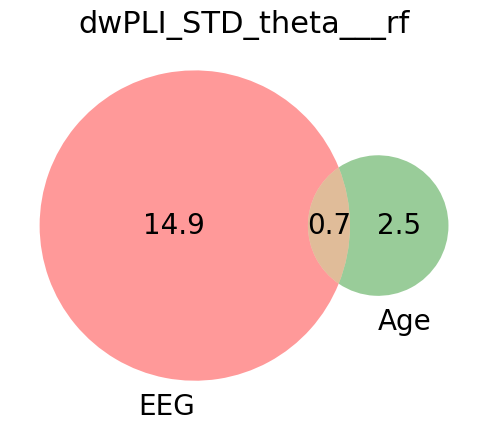

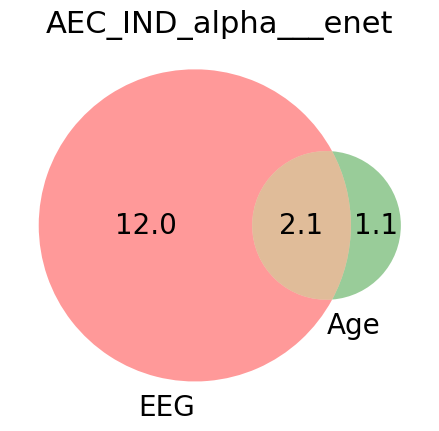

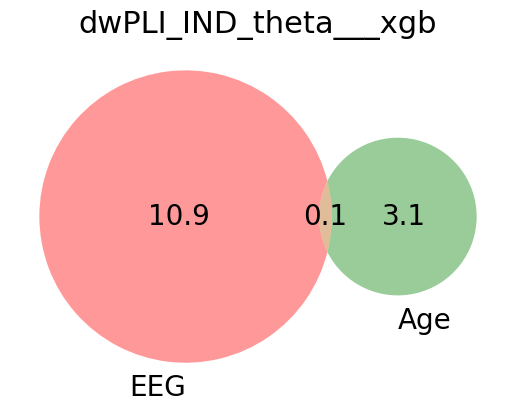

In [ ]:
dset = df_predval_bestmod

for col in dset.columns:
    #
    r2_i = get_r2(dset[col], cog_orig)
    r2_j = get_r2(age_orig, cog_orig)
    r2_ij = get_r2(pd.concat([dset[col], age_orig], axis=1), cog_orig)

    u_i = r2_ij - r2_j
    u_j = r2_ij - r2_i

    c_ij = r2_ij - u_i - u_j


    # Define values
    only_A = round(u_i*100, 1) if u_i >=0 else 0
    only_B = round(u_j*100, 1) if u_j >=0 else 0
    intersection = round(c_ij*100, 1) if c_ij >=0 else 0

    # Create diagram
    v = venn2(subsets=(only_A, only_B, intersection), set_labels=('EEG', 'Age'))

    # Display
    plt.title(col.replace('_diagonal_','_').replace('STD_aec', 'AEC_STD').replace('IND_aec', 'AEC_IND').\
              replace('STD_dwpli', 'dwPLI_STD').replace('IND_dwpli', 'dwPLI_IND')   , fontsize=22 )
    
    # Numbers inside the circles
    for t in v.subset_labels:
        if t:                      # can be None if that region is zero
            t.set_fontsize(20)     # <- choose your size
            # optional: show percent sign
            # t.set_text(f"{float(t.get_text()):.1f}%")

    # Set labels (yours are '', '', but keep this if you add names later)
    for t in v.set_labels:
        if t:
            t.set_fontsize(20)

    plt.show()

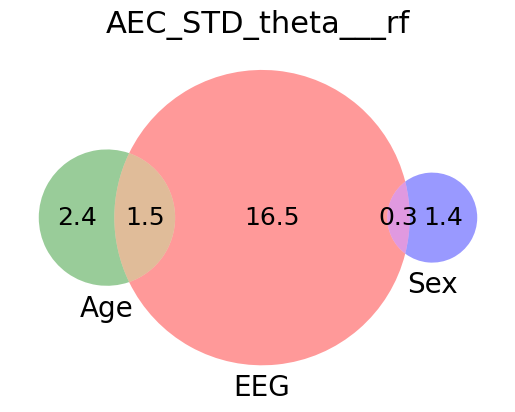

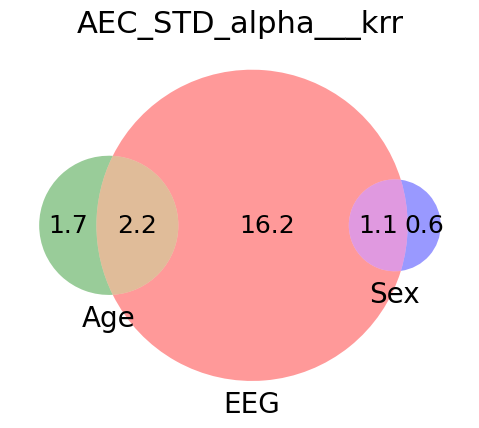

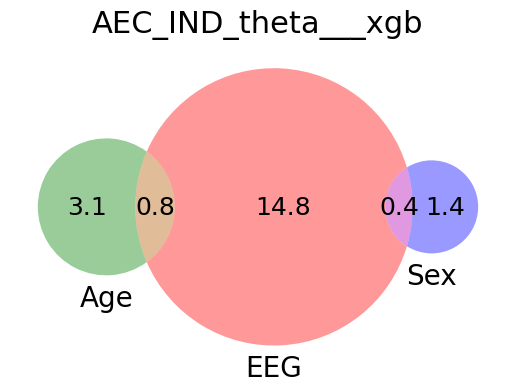

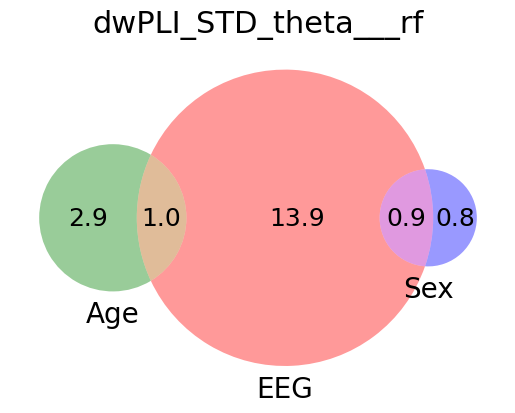

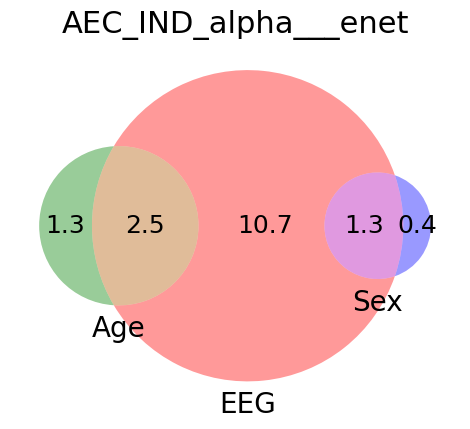

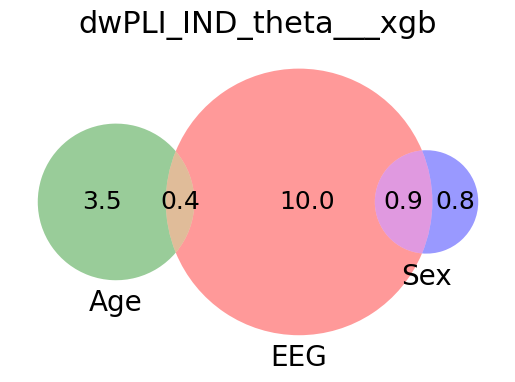

In [85]:
dset = df_predval_bestmod

for col in dset.columns:
    #

    r2_i = get_r2(dset[col], cog_orig)
    r2_j = get_r2(age_orig, cog_orig)
    r2_k = get_r2(sex_bio, cog_orig)

    r2_ij = get_r2(pd.concat([dset[col], age_orig], axis=1), cog_orig)
    r2_ik = get_r2(pd.concat([dset[col], sex_bio], axis=1), cog_orig)
    r2_jk = get_r2(pd.concat([age_orig, sex_bio], axis=1), cog_orig)

    r2_ijk = get_r2(pd.concat([dset[col], age_orig, sex_bio], axis=1), cog_orig)

    u_i = r2_ijk - r2_jk # uniq for i
    u_j = r2_ijk - r2_ik # uniq for j
    u_k = r2_ijk - r2_ij # uniq for k

    c_ij = r2_ik + r2_jk - r2_k - r2_ijk
    c_ik = r2_ij + r2_jk - r2_j - r2_ijk
    c_jk = r2_ij + r2_ik - r2_i - r2_ijk

    c_ijk = r2_i + r2_j + r2_k - r2_ij - r2_ik - r2_jk + r2_ijk

    # Define values
    only_A = round(u_i*100, 1) #if u_i >=0 else 0
    only_B = round(u_j*100, 1) #if u_j >=0 else 0
    only_C = round(u_k*100, 1) #if u_k >=0 else 0
    intersection_AB = round(c_ij*100, 1) if c_ij >=0 else 0
    intersection_AC = round(c_ik*100, 1) if c_ik >=0 else 0
    intersection_BC = round(c_jk*100, 1) if c_jk >=0 else 0
    intersection_ABC = round(c_ijk*100, 1) if c_ijk >=0 else 0

    # Create diagram
    # v3 = venn3(subsets=(only_A, only_B, only_C, intersection_AB, intersection_AC, intersection_BC, intersection_ABC), 
    #      set_labels=('EEG', 'Age', 'Sex'))
    v3 = venn3(
        subsets=(
            only_A,          # EEG only
            only_B,          # Age only
            intersection_AB, # EEG ∩ Age
            only_C,          # Sex only
            intersection_AC, # EEG ∩ Sex
            intersection_BC, # Age ∩ Sex
            intersection_ABC # EEG ∩ Age ∩ Sex
        ),
        set_labels=('EEG', 'Age', 'Sex')
    )

    # Display
    plt.title(col.replace('_diagonal_','_').replace('STD_aec', 'AEC_STD').replace('IND_aec', 'AEC_IND').\
              replace('STD_dwpli', 'dwPLI_STD').replace('IND_dwpli', 'dwPLI_IND')   , fontsize=22 )
    
    # Numbers inside the circles
    for t in v3.subset_labels:
        if t:                      # can be None if that region is zero
            t.set_fontsize(18)     # <- choose your size
            # optional: show percent sign
            # t.set_text(f"{float(t.get_text()):.1f}%")

    # Set labels (yours are '', '', but keep this if you add names later)
    for t in v3.set_labels:
        if t:
            t.set_fontsize(20)

    plt.show()

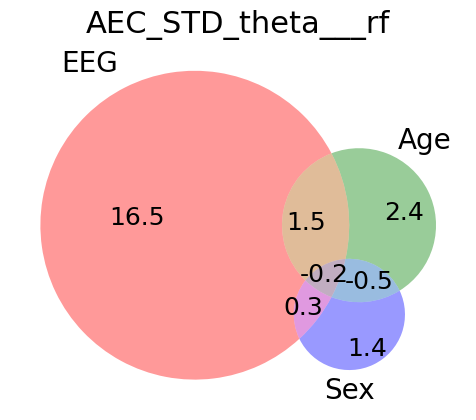

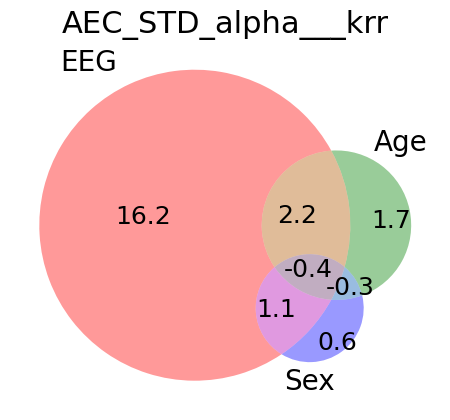

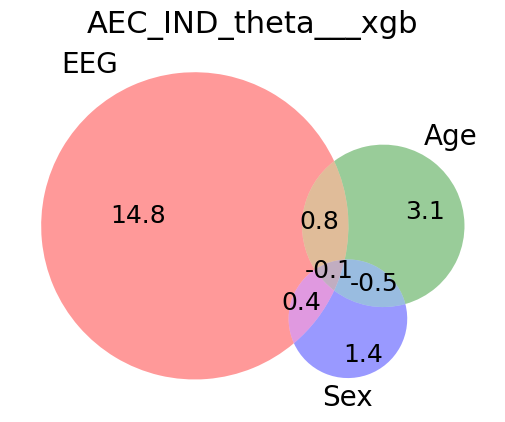

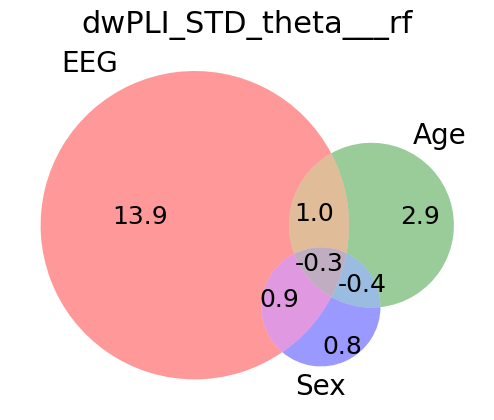

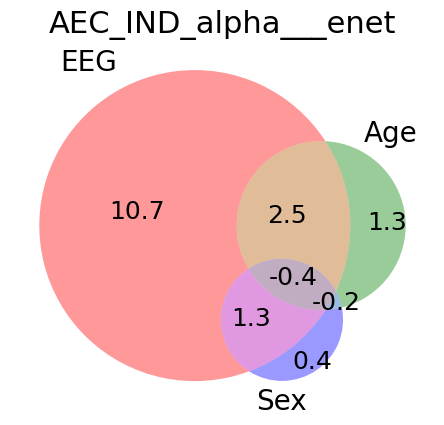

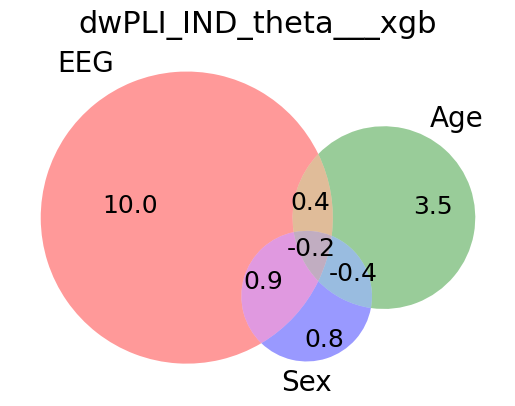

In [82]:
dset = df_predval_bestmod

for col in dset.columns:
    #

    r2_i = get_r2(dset[col], cog_orig)
    r2_j = get_r2(age_orig, cog_orig)
    r2_k = get_r2(sex_bio, cog_orig)

    r2_ij = get_r2(pd.concat([dset[col], age_orig], axis=1), cog_orig)
    r2_ik = get_r2(pd.concat([dset[col], sex_bio], axis=1), cog_orig)
    r2_jk = get_r2(pd.concat([age_orig, sex_bio], axis=1), cog_orig)

    r2_ijk = get_r2(pd.concat([dset[col], age_orig, sex_bio], axis=1), cog_orig)

    u_i = r2_ijk - r2_jk # uniq for i
    u_j = r2_ijk - r2_ik # uniq for j
    u_k = r2_ijk - r2_ij # uniq for k

    c_ij = r2_ik + r2_jk - r2_k - r2_ijk
    c_ik = r2_ij + r2_jk - r2_j - r2_ijk
    c_jk = r2_ij + r2_ik - r2_i - r2_ijk

    c_ijk = r2_i + r2_j + r2_k - r2_ij - r2_ik - r2_jk + r2_ijk

    # Define values
    only_A = round(u_i*100, 1) #if u_i >=0 else 0
    only_B = round(u_j*100, 1) #if u_j >=0 else 0
    only_C = round(u_k*100, 1) #if u_k >=0 else 0
    intersection_AB = round(c_ij*100, 1) #if c_ij >=0 else 0
    intersection_AC = round(c_ik*100, 1) #if c_ik >=0 else 0
    intersection_BC = round(c_jk*100, 1) #if c_jk >=0 else 0
    intersection_ABC = round(c_ijk*100, 1) #if c_ijk >=0 else 0

    # #check
    # print(col.replace('_diagonal_','_').replace('STD_aec', 'AEC_STD').replace('IND_aec', 'AEC_IND').\
    #           replace('STD_dwpli', 'dwPLI_STD').replace('IND_dwpli', 'dwPLI_IND')   )
    # total = u_i + u_j + u_k + c_ij + c_ik + c_jk + c_ijk
    # print(r2_ijk, total)
    # print("R2_i check:", r2_i, u_i + c_ij + c_ik + c_ijk)
    # print("R2_j check:", r2_j, u_j + c_ij + c_jk + c_ijk)
    # print("R2_k check:", r2_k, u_k + c_ik + c_jk + c_ijk)
    


    # Create diagram
    # v3 = venn3(subsets=(only_A, only_B, only_C, intersection_AB, intersection_AC, intersection_BC, intersection_ABC), 
    #      set_labels=('EEG', 'Age', 'Sex'))
    v3 = venn3(
        subsets=(
            only_A,          # EEG only
            only_B,          # Age only
            intersection_AB, # EEG ∩ Age
            only_C,          # Sex only
            intersection_AC, # EEG ∩ Sex
            intersection_BC, # Age ∩ Sex
            intersection_ABC # EEG ∩ Age ∩ Sex
        ),
        set_labels=('EEG', 'Age', 'Sex')
    )

    # Display
    plt.title(col.replace('_diagonal_','_').replace('STD_aec', 'AEC_STD').replace('IND_aec', 'AEC_IND').\
              replace('STD_dwpli', 'dwPLI_STD').replace('IND_dwpli', 'dwPLI_IND')   , fontsize=22 )
    
    # Numbers inside the circles
    for t in v3.subset_labels:
        if t:                      # can be None if that region is zero
            t.set_fontsize(18)     # <- choose your size
            # optional: show percent sign
            # t.set_text(f"{float(t.get_text()):.1f}%")

    # Set labels (yours are '', '', but keep this if you add names later)
    for t in v3.set_labels:
        if t:
            t.set_fontsize(20)

    plt.show()